In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from ultralytics import YOLO
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

In [16]:
# ── Config ────────────────────────────────────────────────────────────
# YOLO_PATH      = "./models/yolov8n_rice_leaf.pt"
YOLO_PATH = r"D:\Python Projects\RicAI_CV\ric_cv\models\yolo\rice_leaf_detect\weights\best.pt"
MOBILENET_PATH = r"D:\Python Projects\RicAI_CV\ric_cv\models\rice_disease_classifier.h5"
# IN_DIST_DIR    = "./data/split/test"    # ảnh lá lúa (in-distribution)
# OOD_DIR        = "./data/ood_samples"  # ảnh không phải lá lúa
IN_DIST_DIR = r"D:\Python Projects\RicAI_CV\ric_cv\data\split\test"
OOD_DIR = r"D:\Python Projects\RicAI_CV\ric_cv\data\ood_samples"
CONF_THRESHOLD = 0.4
PADDING        = 10

CLASS_NAMES = [
    "bacterial_blight", "barrow_brown_leaf_spot", "brown_spot",
    "healthy", "leaf_blast", "leaf_scald", "leaf_smut",
    "neck_blast", "rice_hispa", "sheath_blight", "tungro",
]

In [17]:
# ── Load models ───────────────────────────────────────────────────────
yolo      = YOLO(YOLO_PATH)
mobilenet = tf.keras.models.load_model(MOBILENET_PATH)
print("✅ Models loaded")

✅ Models loaded


In [18]:
def get_msp(img_bgr):
    """
    Chạy full pipeline và trả về Maximum Softmax Probability.
    Nếu YOLO không detect → dùng ảnh gốc (fallback).
    """
    h, w = img_bgr.shape[:2]
    results = yolo.predict(img_bgr, conf=CONF_THRESHOLD, verbose=False)
    boxes   = results[0].boxes

    if boxes is not None and len(boxes) > 0:
        xyxy  = boxes.xyxy.cpu().numpy()
        areas = (xyxy[:, 2]-xyxy[:, 0]) * (xyxy[:, 3]-xyxy[:, 1])
        best  = np.argmax(areas)
        x1, y1, x2, y2 = xyxy[best].astype(int)
        x1=max(0,x1-PADDING); y1=max(0,y1-PADDING)
        x2=min(w,x2+PADDING); y2=min(h,y2+PADDING)
        crop = img_bgr[y1:y2, x1:x2]
    else:
        crop = img_bgr  # fallback

    crop_224 = cv2.resize(crop, (224, 224))
    img_rgb  = cv2.cvtColor(crop_224, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    probs    = mobilenet.predict(np.expand_dims(img_rgb, 0), verbose=0)[0]
    return float(np.max(probs))

In [22]:
# ── Thu thập MSP scores ───────────────────────────────────────────────
print("\nScoring in-distribution samples (lá lúa)...")
in_scores = []
for cls in os.listdir(IN_DIST_DIR):
    cls_dir = os.path.join(IN_DIST_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    imgs = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for img_file in imgs[:100]:  # lấy 50 ảnh mỗi class
        img = cv2.imread(os.path.join(cls_dir, img_file))
        if img is not None:
            in_scores.append(get_msp(img))
print(f"  → {len(in_scores)} in-distribution samples")

print("\nScoring OOD samples (ảnh không phải lá lúa)...")
ood_scores = []
ood_imgs = [f for f in os.listdir(OOD_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))]
for img_file in ood_imgs:
    img = cv2.imread(os.path.join(OOD_DIR, img_file))
    if img is not None:
        ood_scores.append(get_msp(img))
print(f"  → {len(ood_scores)} OOD samples")


Scoring in-distribution samples (lá lúa)...
  → 945 in-distribution samples

Scoring OOD samples (ảnh không phải lá lúa)...
  → 802 OOD samples


In [23]:
# ── Prepare labels ─────────────────────────────────────
y_true = np.array(
    [1] * len(in_scores) +
    [0] * len(ood_scores)
)

y_scores = np.array(in_scores + ood_scores)

# ── ROC Curve ──────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# ── Best threshold (Youden’s J statistic) ──────────────
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)

best_threshold = thresholds[best_idx]

print(f"\nBest Threshold = {best_threshold:.4f}")
print(f"TPR = {tpr[best_idx]:.4f}")
print(f"FPR = {fpr[best_idx]:.4f}")
print(f"AUC = {roc_auc:.4f}")


Best Threshold = 0.8649
TPR = 0.6296
FPR = 0.2556
AUC = 0.7270


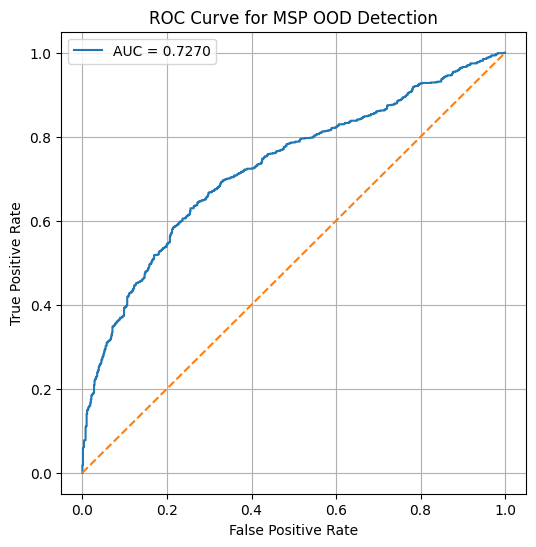

In [24]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for MSP OOD Detection")
plt.legend()
plt.grid(True)
plt.show()